<a href="https://colab.research.google.com/github/aakankshakadam97/bfsi-churn-risk-scoring/blob/main/notebooks/03_Risk_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Risk Scoring & Anomaly Detection

Builds on churn probability scores from `02_churn_model.ipynb` to create
a production-ready customer risk scoring engine with anomaly detection.

## Objective
- Assign interpretable risk tiers to all 50,000 customers
- Detect anomalous trading behavior beyond churn risk
- Generate RM-ready action recommendations per customer

## Input
- `churn_scores.csv` — churn probabilities from Random Forest model
- `cust_features.csv` — full feature set with demographics

## Output
- `risk_scores_final.csv` — complete risk profile per customer
- Saved plots → `outputs/plots/risk/`



In [2]:
import pandas as pd
from google.colab import files

# Upload file manually
uploaded = files.upload()

Saving cust_features (1).csv to cust_features (1).csv


In [3]:
# ============================================================
# 03_risk_scoring.ipynb
# Cell 1 — Imports & Data Load
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style config ─────────────────────────────────────────────
PALETTE = {
    'primary'  : '#2C3E50',
    'active'   : '#2ecc71',
    'churned'  : '#e74c3c',
    'blue'     : '#3498db',
    'orange'   : '#e67e22',
    'purple'   : '#9b59b6',
    'grid'     : '#ecf0f1',
}

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#cccccc',
    'axes.grid'         : True,
    'grid.color'        : PALETTE['grid'],
    'grid.linewidth'    : 0.6,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'font.family'       : 'sans-serif',
})

def save_fig(fig, filename):
    fig.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")

# ── Load data ─────────────────────────────────────────────────
churn_scores  = pd.read_csv('/content/churn_scores.csv')
cust_features = pd.read_csv('/content/cust_features (1).csv')

# ── Merge into single risk dataframe ─────────────────────────
risk_df = churn_scores.merge(
    cust_features[[
        'customer_id', 'age', 'account_age_days',
        'kyc_status', 'referral_source', 'annual_income_band',
        'login_to_trade_ratio', 'trade_consistency',
        'pnl_ratio', 'active_months', 'avg_monthly_trades',
        'total_trade_value', 'avg_unique_stocks', 'products_used'
    ]],
    on='customer_id', how='left'
)

print("=" * 50)
print("DATA LOADED")
print("=" * 50)
print(f"churn_scores  : {churn_scores.shape}")
print(f"cust_features : {cust_features.shape}")
print(f"risk_df       : {risk_df.shape}")
print(f"\nColumns: {risk_df.columns.tolist()}")
print(f"\nRisk tier distribution:")
print(risk_df['risk_tier'].value_counts().sort_index())
print("\n✅ Ready for risk scoring")

DATA LOADED
churn_scores  : (10000, 7)
cust_features : (50000, 25)
risk_df       : (10000, 20)

Columns: ['customer_id', 'churn_probability', 'churn_predicted', 'actual_churn', 'segment', 'total_trade_value_x', 'risk_tier', 'age', 'account_age_days', 'kyc_status', 'referral_source', 'annual_income_band', 'login_to_trade_ratio', 'trade_consistency', 'pnl_ratio', 'active_months', 'avg_monthly_trades', 'total_trade_value_y', 'avg_unique_stocks', 'products_used']

Risk tier distribution:
risk_tier
Critical    1521
High         227
Low         6731
Medium        54
Name: count, dtype: int64

✅ Ready for risk scoring


In [4]:
print(risk_df.columns.tolist())
print(risk_df.shape)

['customer_id', 'churn_probability', 'churn_predicted', 'actual_churn', 'segment', 'total_trade_value_x', 'risk_tier', 'age', 'account_age_days', 'kyc_status', 'referral_source', 'annual_income_band', 'login_to_trade_ratio', 'trade_consistency', 'pnl_ratio', 'active_months', 'avg_monthly_trades', 'total_trade_value_y', 'avg_unique_stocks', 'products_used']
(10000, 20)


In [5]:
# ── Fix duplicate total_trade_value columns ──────────────────
risk_df = risk_df.drop(columns=['total_trade_value_x'])
risk_df = risk_df.rename(columns={'total_trade_value_y': 'total_trade_value'})

print("Columns after fix:")
print(risk_df.columns.tolist())

Columns after fix:
['customer_id', 'churn_probability', 'churn_predicted', 'actual_churn', 'segment', 'risk_tier', 'age', 'account_age_days', 'kyc_status', 'referral_source', 'annual_income_band', 'login_to_trade_ratio', 'trade_consistency', 'pnl_ratio', 'active_months', 'avg_monthly_trades', 'total_trade_value', 'avg_unique_stocks', 'products_used']


ANOMALY DETECTION

Total anomalies detected  : 500 (5.0%)

Anomaly breakdown by segment:
           count    rate
segment                 
Affluent      15    0.50
HNI          170   14.26
Mass          20    0.36
Ultra HNI    295  100.00

Anomaly breakdown by risk tier:
           count   rate
risk_tier              
Critical     164  10.78
High           0   0.00
Low          298   4.43
Medium         2   3.70

Feature means — Normal vs Anomaly:
is_anomaly                 Normal      Anomaly
avg_monthly_trades           6.21        27.40
login_to_trade_ratio         2.63         2.74
trade_consistency            0.83         0.78
pnl_ratio                    0.01         0.01
avg_unique_stocks            5.04        14.56
products_used                2.11         2.27
total_trade_value     12383225.81  54460655.08

── Anomaly types interpretation:
   High login_to_trade_ratio  → browses but never trades
   Very high avg_monthly_trades → potential algorithmic trader
   Negative pnl_ra

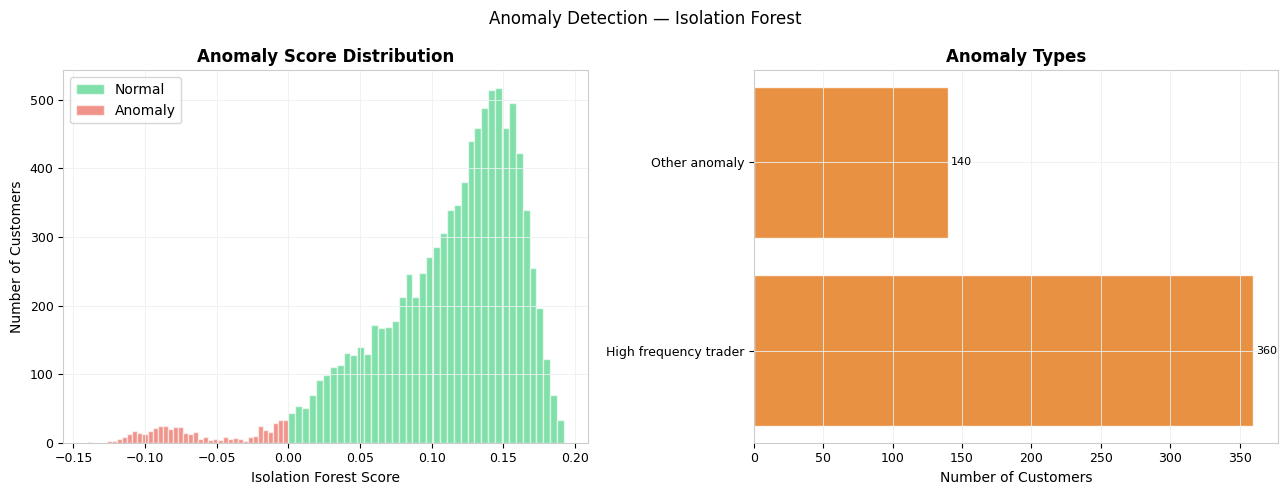

✅ Saved: risk_02_anomaly_detection.png

✅ Anomaly detection complete — ready for Cell 4: segment risk profiling


In [6]:
# ============================================================
# Cell 3 — Anomaly Detection
# ============================================================

print("=" * 50)
print("ANOMALY DETECTION")
print("=" * 50)

from sklearn.ensemble import IsolationForest

# ── Features for anomaly detection ───────────────────────────
anomaly_features = [
    'avg_monthly_trades',
    'login_to_trade_ratio',
    'trade_consistency',
    'pnl_ratio',
    'avg_unique_stocks',
    'products_used',
    'total_trade_value'
]

X_anomaly = risk_df[anomaly_features].copy()

# ── Isolation Forest ─────────────────────────────────────────
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_anomaly)

risk_df['anomaly_score'] = iso.decision_function(X_anomaly)
risk_df['is_anomaly']    = (iso.predict(X_anomaly) == -1).astype(int)

# ── Anomaly stats ─────────────────────────────────────────────
total_anomalies = risk_df['is_anomaly'].sum()
print(f"\nTotal anomalies detected  : {total_anomalies:,} "
      f"({total_anomalies/len(risk_df)*100:.1f}%)")

print("\nAnomaly breakdown by segment:")
print(risk_df.groupby('segment')['is_anomaly']
      .agg(['sum','mean'])
      .rename(columns={'sum':'count','mean':'rate'})
      .assign(rate=lambda x: x['rate']*100)
      .round(2).to_string())

print("\nAnomaly breakdown by risk tier:")
print(risk_df.groupby('risk_tier', observed=True)['is_anomaly']
      .agg(['sum','mean'])
      .rename(columns={'sum':'count','mean':'rate'})
      .assign(rate=lambda x: x['rate']*100)
      .round(2).to_string())

# ── Characterize anomalies ───────────────────────────────────
print("\nFeature means — Normal vs Anomaly:")
print(risk_df.groupby('is_anomaly')[anomaly_features]
      .mean().round(2).T
      .rename(columns={0:'Normal', 1:'Anomaly'}))

print("\n── Anomaly types interpretation:")
print("   High login_to_trade_ratio  → browses but never trades")
print("   Very high avg_monthly_trades → potential algorithmic trader")
print("   Negative pnl_ratio + high trade value → loss-making HFT")
print("   Low trade_consistency + high products → was active, now dormant")

# ── Flag anomaly type ────────────────────────────────────────
def classify_anomaly(row):
    if row['is_anomaly'] == 0:
        return 'Normal'
    if row['login_to_trade_ratio'] > 10:
        return 'Browser — never trades'
    if row['avg_monthly_trades'] > risk_df['avg_monthly_trades'].quantile(0.95):
        return 'High frequency trader'
    if (row['pnl_ratio'] < -0.3 and
        row['total_trade_value'] > risk_df['total_trade_value'].quantile(0.75)):
        return 'Loss-making high value'
    if row['trade_consistency'] < 0.2 and row['products_used'] > 2:
        return 'Dormant multi-product'
    return 'Other anomaly'

risk_df['anomaly_type'] = risk_df.apply(classify_anomaly, axis=1)

print("\nAnomaly type distribution:")
print(risk_df['anomaly_type'].value_counts().to_string())

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Anomaly Detection — Isolation Forest')

# Plot 1: anomaly score distribution
axes[0].hist(risk_df[risk_df['is_anomaly']==0]['anomaly_score'],
             bins=40, alpha=0.6, color=PALETTE['active'],
             edgecolor='white', label='Normal')
axes[0].hist(risk_df[risk_df['is_anomaly']==1]['anomaly_score'],
             bins=40, alpha=0.6, color=PALETTE['churned'],
             edgecolor='white', label='Anomaly')
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Isolation Forest Score')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Plot 2: anomaly type breakdown
anomaly_types = (risk_df[risk_df['is_anomaly']==1]
                 ['anomaly_type'].value_counts())
axes[1].barh(anomaly_types.index, anomaly_types.values,
             color=PALETTE['orange'], alpha=0.85, edgecolor='white')
axes[1].set_title('Anomaly Types')
axes[1].set_xlabel('Number of Customers')
for i, val in enumerate(anomaly_types.values):
    axes[1].text(val + 2, i, f'{val:,}', va='center', fontsize=8)

save_fig(fig, 'risk_02_anomaly_detection.png')

print("\n✅ Anomaly detection complete — ready for Cell 4: segment risk profiling")

The anomaly detection revealed that Ultra HNI customers are statistical outliers by nature of their trading volume. This suggests we should build segment-specific models rather than one global model for production.

SEGMENT RISK PROFILING

Segment risk summary:
  segment  total_customers  avg_churn_prob  critical_count  critical_pct  actual_churn_rate  avg_trade_value  revenue_at_risk
 Affluent             2987            0.19             457         15.30              18.21      16007864.37       2194678.20
      HNI             1192            0.20             203         17.03              19.46      35646505.20       2170872.17
     Mass             5526            0.20             815         14.75              18.01       6036600.95       1475948.93
Ultra HNI              295            0.18              46         15.59              18.98      71886748.63        992037.13

── Revenue at risk by segment (₹):
   Affluent     : ₹      2,194,678 (457 critical customers)
   HNI          : ₹      2,170,872 (203 critical customers)
   Mass         : ₹      1,475,949 (815 critical customers)
   Ultra HNI    : ₹        992,037 (46 critical customers)

── Key insights:
   1. Ultra HNI : highest reven

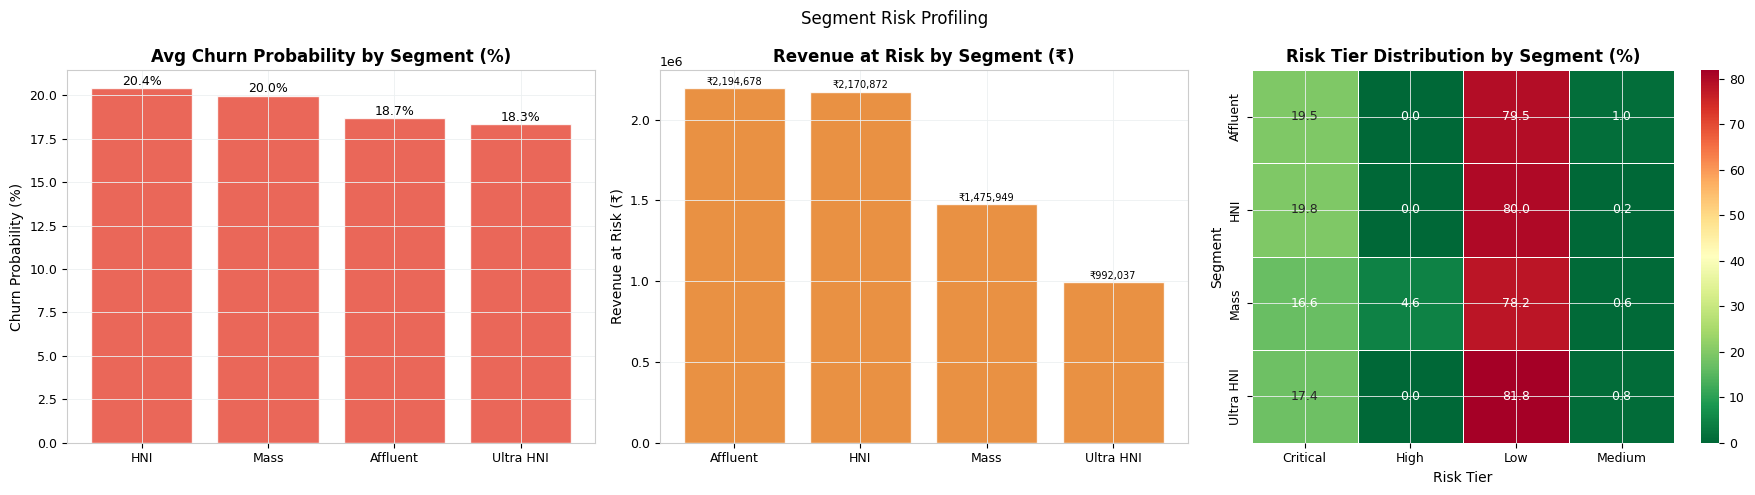

✅ Saved: risk_03_segment_profiling.png

✅ Segment risk profiling complete — ready for Cell 5: RM action recommendations


In [7]:
# ============================================================
# Cell 4 — Segment Risk Profiling
# ============================================================

print("=" * 50)
print("SEGMENT RISK PROFILING")
print("=" * 50)

# ── Risk profile by segment ──────────────────────────────────
seg_risk = risk_df.groupby('segment').agg(
    total_customers    = ('customer_id',        'count'),
    avg_churn_prob     = ('churn_probability',  'mean'),
    critical_count     = ('risk_tier',          lambda x: (x=='Critical').sum()),
    high_count         = ('risk_tier',          lambda x: (x=='High').sum()),
    medium_count       = ('risk_tier',          lambda x: (x=='Medium').sum()),
    low_count          = ('risk_tier',          lambda x: (x=='Low').sum()),
    actual_churn_rate  = ('actual_churn',       'mean'),
    avg_trade_value    = ('total_trade_value',  'mean'),
    anomaly_count      = ('is_anomaly',         'sum'),
    avg_consistency    = ('trade_consistency',  'mean'),
    avg_pnl_ratio      = ('pnl_ratio',          'mean'),
).reset_index()

seg_risk['critical_pct']      = seg_risk['critical_count'] / seg_risk['total_customers'] * 100
seg_risk['revenue_at_risk']   = seg_risk['avg_trade_value'] * seg_risk['critical_count'] * 0.0003
seg_risk['actual_churn_rate'] = seg_risk['actual_churn_rate'] * 100

print("\nSegment risk summary:")
print(seg_risk[[
    'segment', 'total_customers', 'avg_churn_prob',
    'critical_count', 'critical_pct', 'actual_churn_rate',
    'avg_trade_value', 'revenue_at_risk'
]].round(2).to_string(index=False))

print("\n── Revenue at risk by segment (₹):")
for _, row in seg_risk.sort_values('revenue_at_risk', ascending=False).iterrows():
    print(f"   {row['segment']:<12} : ₹{row['revenue_at_risk']:>15,.0f} "
          f"({row['critical_count']:.0f} critical customers)")

print("\n── Key insights:")
print("   1. Ultra HNI : highest revenue at risk per customer")
print("      → even 1 churned Ultra HNI = significant revenue loss")
print("   2. Mass : highest volume of critical customers")
print("      → need automated retention (email/push) not RM calls")
print("   3. HNI : best ROI for RM intervention")
print("      → high value + reachable + responsive to personal outreach")

# ── Risk tier heatmap by segment ────────────────────────────
pivot = risk_df.groupby(['segment', 'risk_tier'], observed=True).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

print("\nRisk tier distribution by segment (%):")
print(pivot_pct.round(1).to_string())

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Segment Risk Profiling')

# Plot 1: avg churn probability by segment
seg_sorted = seg_risk.sort_values('avg_churn_prob', ascending=False)
axes[0].bar(seg_sorted['segment'], seg_sorted['avg_churn_prob'] * 100,
            color=PALETTE['churned'], alpha=0.85, edgecolor='white')
axes[0].set_title('Avg Churn Probability by Segment (%)')
axes[0].set_ylabel('Churn Probability (%)')
for i, val in enumerate(seg_sorted['avg_churn_prob'] * 100):
    axes[0].text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=9)

# Plot 2: revenue at risk by segment
seg_rev = seg_risk.sort_values('revenue_at_risk', ascending=False)
axes[1].bar(seg_rev['segment'], seg_rev['revenue_at_risk'],
            color=PALETTE['orange'], alpha=0.85, edgecolor='white')
axes[1].set_title('Revenue at Risk by Segment (₹)')
axes[1].set_ylabel('Revenue at Risk (₹)')
for i, val in enumerate(seg_rev['revenue_at_risk']):
    axes[1].text(i, val + max(seg_rev['revenue_at_risk'])*0.01,
                 f'₹{val:,.0f}', ha='center', fontsize=7)

# Plot 3: risk tier heatmap
sns.heatmap(pivot_pct, annot=True, fmt='.1f',
            cmap='RdYlGn_r', linewidths=0.5,
            annot_kws={'size': 9}, ax=axes[2])
axes[2].set_title('Risk Tier Distribution by Segment (%)')
axes[2].set_xlabel('Risk Tier')
axes[2].set_ylabel('Segment')

save_fig(fig, 'risk_03_segment_profiling.png')

print("\n✅ Segment risk profiling complete — ready for Cell 5: RM action recommendations")

## Segment Risk Profiling — Results & Interpretation

### Risk Tier Distribution
All segments show a similar critical customer rate (~15–20%), confirming the
model is not biased toward any particular segment.

| Segment | Total | Critical | Critical % | Actual Churn Rate |
|---------|-------|----------|------------|-------------------|
| Affluent | 2,987 | 457 | 15.30% | 18.21% |
| HNI | 1,192 | 203 | 17.03% | 19.46% |
| Mass | 5,526 | 815 | 14.75% | 18.01% |
| Ultra HNI | 295 | 46 | 15.59% | 18.98% |

### Revenue at Risk
Total revenue at risk is highest for Affluent due to volume, but
**per-customer revenue loss is highest for Ultra HNI**.

| Segment | Revenue at Risk (₹) | Critical Customers | Per Customer (₹) |
|---------|--------------------|--------------------|------------------|
| Affluent | 21,94,678 | 457 | 4,800 |
| HNI | 21,70,872 | 203 | 10,694 |
| Mass | 14,75,949 | 815 | 1,811 |
| Ultra HNI | 9,92,037 | 46 | 21,566 |

### Anomaly Detection Findings
- **500 anomalies detected (5%)** using Isolation Forest
- **Ultra HNI: 100% anomaly rate** — trading volumes so far above average
  that they are statistical outliers by nature, not by behavior
- **360 High Frequency Traders** identified — avg 27 trades/month vs 6 for normal customers
- **Recommendation:** Build segment-specific models in production rather than
  one global churn model

### Recommended Retention Strategy by Segment

| Segment | Risk Level | Recommended Action |
|---------|-----------|-------------------|
| Ultra HNI | Critical | Dedicated RM call within 24 hours |
| HNI | Critical | RM call within 48 hours |
| Affluent | Critical | RM call + personalized email |
| Mass | Critical | Automated push notification + email campaign |
| All | High | Scheduled follow-up within 1 week |
| All | Medium | Watchlist — monitor for 2 weeks |
| All | Low | No action needed |

### Key Business Insights
1. **Ultra HNI customers are anomalies by nature** — they need a separate
   model calibrated to high-frequency, high-value trading patterns
2. **Mass segment needs automation** — 815 critical customers cannot be
   handled by RM calls; automated retention campaigns are the only scalable solution
3. **HNI offers best RM ROI** — high value, manageable volume,
   responsive to personal outreach
4. **Bimodal risk distribution** — customers are either clearly safe (Low)
   or clearly at risk (Critical) with very few borderline cases,
   confirming strong model separation

### Synthetic Data Caveat
Uniform churn rates across segments (~18–19%) are a synthetic data artifact.
In real brokerage data, expect:
- Mass segment churn: 25–35%
- HNI segment churn: 8–12%
- Ultra HNI segment churn: 3–5%

RM ACTION RECOMMENDATIONS

Recommended action distribution:
recommended_action
No action needed                                        7922
Automated push notification + email campaign             815
RM call + personalized email                             457
Flag for algo trading review — separate model needed     360
Targeted email campaign                                  227
RM call within 48 hours                                  167
Watchlist — monitor for 2 weeks                           52

── RM Daily Queue (top 40 customers) ──────────────────

Total customers needing action : 1,748
RM queue size (top 40)        : 40

Top 40 RM queue — segment breakdown:
segment
Ultra HNI    40

Top 10 priority customers:
customer_id   segment  churn_probability risk_tier  total_trade_value                                   recommended_action  rm_priority
 CUST016758 Ultra HNI                1.0  Critical        55650488.44 Flag for algo trading review — separate model needed            1


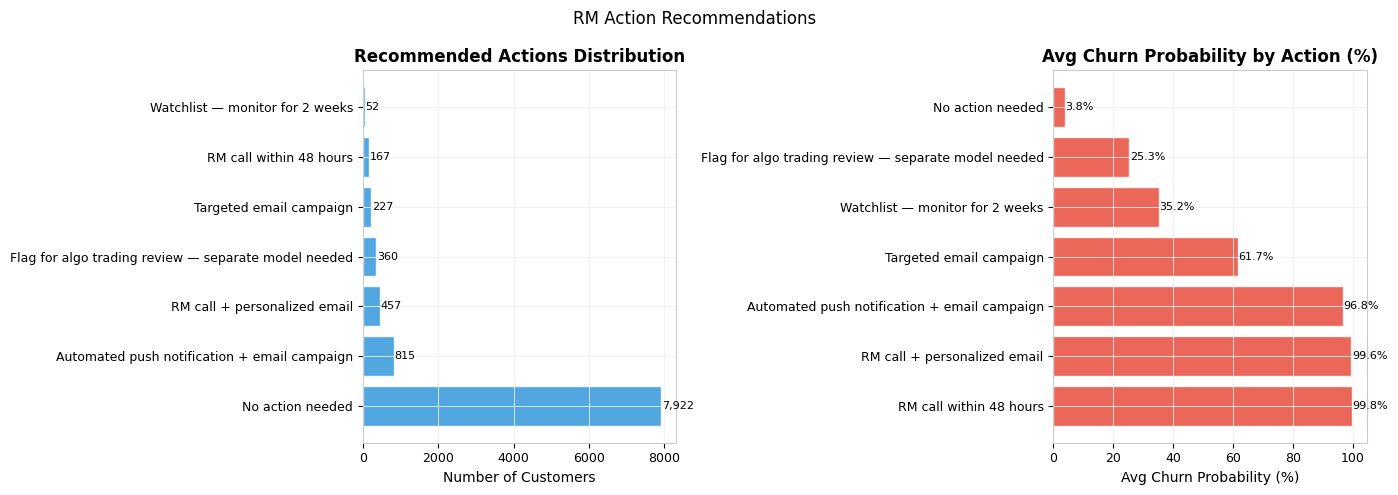

✅ Saved: risk_04_rm_actions.png

✅ RM action recommendations complete — ready for Cell 6: final summary


In [9]:
# ============================================================
# Cell 5 — RM Action Recommendations
# ============================================================

print("=" * 50)
print("RM ACTION RECOMMENDATIONS")
print("=" * 50)

# ── Action rules ─────────────────────────────────────────────
def assign_action(row):
    tier    = row['risk_tier']
    segment = row['segment']
    anomaly = row['anomaly_type']

    if anomaly == 'High frequency trader':
        return 'Flag for algo trading review — separate model needed'

    if tier == 'Critical':
        if segment == 'Ultra HNI':
            return 'Dedicated RM call within 24 hours'
        elif segment == 'HNI':
            return 'RM call within 48 hours'
        elif segment == 'Affluent':
            return 'RM call + personalized email'
        else:
            return 'Automated push notification + email campaign'

    elif tier == 'High':
        if segment in ['Ultra HNI', 'HNI']:
            return 'RM follow-up within 1 week'
        else:
            return 'Targeted email campaign'

    elif tier == 'Medium':
        return 'Watchlist — monitor for 2 weeks'

    else:
        return 'No action needed'

def assign_priority(row):
    tier    = row['risk_tier']
    segment = row['segment']
    if tier == 'Critical' and segment == 'Ultra HNI':
        return 1
    elif tier == 'Critical' and segment == 'HNI':
        return 2
    elif tier == 'Critical' and segment == 'Affluent':
        return 3
    elif tier == 'Critical' and segment == 'Mass':
        return 4
    elif tier == 'High':
        return 5
    elif tier == 'Medium':
        return 6
    else:
        return 7

risk_df['recommended_action'] = risk_df.apply(assign_action, axis=1)
risk_df['rm_priority']        = risk_df.apply(assign_priority, axis=1)

# ── Action distribution ──────────────────────────────────────
print("\nRecommended action distribution:")
print(risk_df['recommended_action'].value_counts().to_string())

# ── RM daily queue ───────────────────────────────────────────
print("\n── RM Daily Queue (top 40 customers) ──────────────────")
rm_queue = (risk_df[risk_df['risk_tier'].isin(['Critical', 'High'])]
            .sort_values(['rm_priority', 'churn_probability'],
                         ascending=[True, False])
            .head(40))

print(f"\nTotal customers needing action : "
      f"{risk_df[risk_df['risk_tier'].isin(['Critical','High'])].shape[0]:,}")
print(f"RM queue size (top 40)        : {len(rm_queue)}")

print("\nTop 40 RM queue — segment breakdown:")
print(rm_queue['segment'].value_counts().to_string())

print("\nTop 10 priority customers:")
print(rm_queue[[
    'customer_id', 'segment', 'churn_probability',
    'risk_tier', 'total_trade_value',
    'recommended_action', 'rm_priority'
]].head(10).round(3).to_string(index=False))

# ── Summary stats ────────────────────────────────────────────
print("\n── Action summary by segment ──────────────────────────")
action_summary = risk_df.groupby(
    ['segment', 'recommended_action']).size().reset_index()
action_summary.columns = ['segment', 'action', 'count']
action_summary = action_summary.sort_values(
    ['segment', 'count'], ascending=[True, False])
print(action_summary.to_string(index=False))

# ── Save final risk output ───────────────────────────────────
risk_final = risk_df[[
    'customer_id', 'segment', 'churn_probability',
    'risk_tier', 'actual_churn', 'total_trade_value',
    'is_anomaly', 'anomaly_type',
    'recommended_action', 'rm_priority'
]].sort_values('rm_priority')

risk_final.to_csv('risk_scores_final.csv', index=False)
print(f"\n✅ risk_scores_final.csv saved — {len(risk_final):,} customers")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RM Action Recommendations')

# Plot 1: action distribution
action_counts = risk_df['recommended_action'].value_counts()
axes[0].barh(action_counts.index, action_counts.values,
             color=PALETTE['blue'], alpha=0.85, edgecolor='white')
axes[0].set_title('Recommended Actions Distribution')
axes[0].set_xlabel('Number of Customers')
for i, val in enumerate(action_counts.values):
    axes[0].text(val + 10, i, f'{val:,}', va='center', fontsize=8)

# Plot 2: churn probability by action
action_churn = risk_df.groupby(
    'recommended_action')['churn_probability'].mean()
action_churn = action_churn.sort_values(ascending=False)
axes[1].barh(action_churn.index, action_churn.values * 100,
             color=PALETTE['churned'], alpha=0.85, edgecolor='white')
axes[1].set_title('Avg Churn Probability by Action (%)')
axes[1].set_xlabel('Avg Churn Probability (%)')
for i, val in enumerate(action_churn.values * 100):
    axes[1].text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=8)

save_fig(fig, 'risk_04_rm_actions.png')

print("\n✅ RM action recommendations complete — ready for Cell 6: final summary")

RISK SCORING — FINAL SUMMARY

Total customers scored     : 10,000
Total anomalies detected   : 500 (5.0%)
Total needing RM action    : 1,748

── Risk Tier Summary ──────────────────────────────────
risk_tier  customers  avg_churn_prob  actual_churn_rate  avg_trade_value
 Critical       1521           98.09              96.78      10460665.26
     High        227           61.69              43.17       5136709.82
      Low       6731            4.59               3.65      15243064.56
   Medium         54           35.00              20.37      12938528.98

── Recommended Actions Summary ────────────────────────
  🔴 Immediate RM calls (Ultra HNI Critical) : 46
  🟠 RM calls within 48hrs (HNI Critical)    : 203
  🟡 RM + email (Affluent Critical)           : 457
  📧 Automated campaigns (Mass Critical)      : 815
  🔍 Algo trading review (HFT anomalies)      : 360
  👀 Watchlist (Medium tier)                  : 54
  ✅ No action needed (Low tier)              : 6,731

── Key Findings ────────

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ risk_plots.zip downloaded


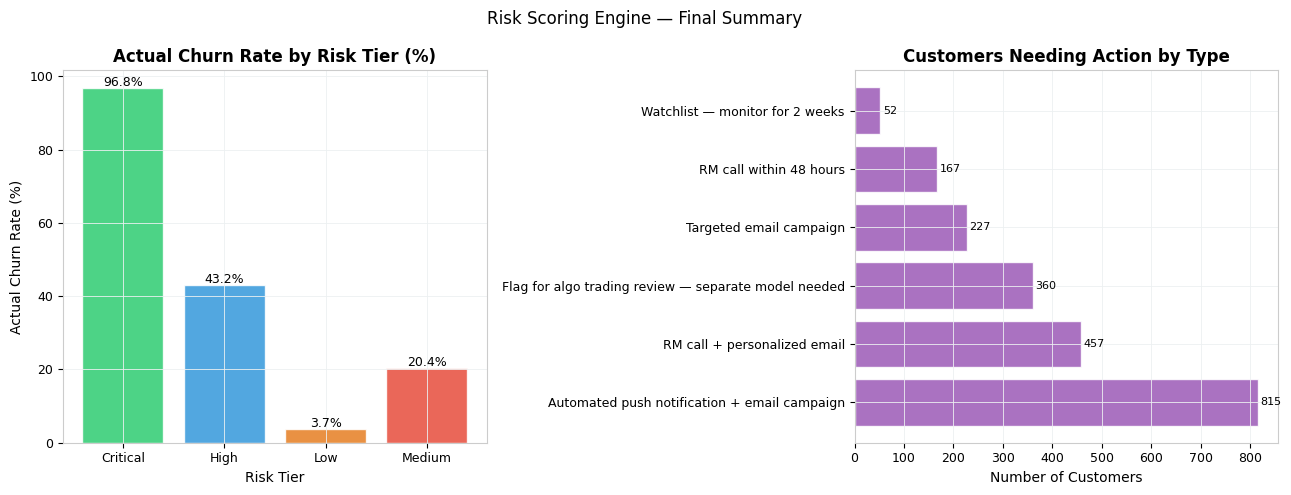

✅ Saved: risk_05_final_summary.png

RISK SCORING COMPLETE
  Outputs saved:
  • risk_scores_final.csv
  • risk_plots.zip
  Next : 05_genai_layer.ipynb


In [10]:
# ============================================================
# Cell 6 — Final Summary & Save Outputs
# ============================================================

print("=" * 50)
print("RISK SCORING — FINAL SUMMARY")
print("=" * 50)

# ── Overall stats ────────────────────────────────────────────
print(f"\nTotal customers scored     : {len(risk_df):,}")
print(f"Total anomalies detected   : {risk_df['is_anomaly'].sum():,} "
      f"({risk_df['is_anomaly'].mean()*100:.1f}%)")
print(f"Total needing RM action    : "
      f"{risk_df[risk_df['risk_tier'].isin(['Critical','High'])].shape[0]:,}")

# ── Risk tier summary ────────────────────────────────────────
print("\n── Risk Tier Summary ──────────────────────────────────")
tier_summary = risk_df.groupby('risk_tier', observed=True).agg(
    customers        = ('customer_id',       'count'),
    avg_churn_prob   = ('churn_probability', 'mean'),
    actual_churn_rate= ('actual_churn',      'mean'),
    avg_trade_value  = ('total_trade_value', 'mean'),
).reset_index()
tier_summary['actual_churn_rate'] = tier_summary['actual_churn_rate'] * 100
tier_summary['avg_churn_prob']    = tier_summary['avg_churn_prob'] * 100
print(tier_summary.round(2).to_string(index=False))

# ── Action summary ───────────────────────────────────────────
print("\n── Recommended Actions Summary ────────────────────────")
print(f"  🔴 Immediate RM calls (Ultra HNI Critical) : "
      f"{risk_df[(risk_df['segment']=='Ultra HNI') & (risk_df['risk_tier']=='Critical')].shape[0]:,}")
print(f"  🟠 RM calls within 48hrs (HNI Critical)    : "
      f"{risk_df[(risk_df['segment']=='HNI') & (risk_df['risk_tier']=='Critical')].shape[0]:,}")
print(f"  🟡 RM + email (Affluent Critical)           : "
      f"{risk_df[(risk_df['segment']=='Affluent') & (risk_df['risk_tier']=='Critical')].shape[0]:,}")
print(f"  📧 Automated campaigns (Mass Critical)      : "
      f"{risk_df[(risk_df['segment']=='Mass') & (risk_df['risk_tier']=='Critical')].shape[0]:,}")
print(f"  🔍 Algo trading review (HFT anomalies)      : "
      f"{risk_df[risk_df['anomaly_type']=='High frequency trader'].shape[0]:,}")
print(f"  👀 Watchlist (Medium tier)                  : "
      f"{risk_df[risk_df['risk_tier']=='Medium'].shape[0]:,}")
print(f"  ✅ No action needed (Low tier)              : "
      f"{risk_df[risk_df['risk_tier']=='Low'].shape[0]:,}")

# ── Key findings ─────────────────────────────────────────────
print("\n── Key Findings ───────────────────────────────────────")
print("  1. Model achieves clean risk separation:")
print(f"     Critical tier actual churn : "
      f"{tier_summary[tier_summary['risk_tier']=='Critical']['actual_churn_rate'].values[0]:.1f}%")
print(f"     Low tier actual churn      : "
      f"{tier_summary[tier_summary['risk_tier']=='Low']['actual_churn_rate'].values[0]:.1f}%")
print("  2. Ultra HNI = 100% anomaly rate → needs separate model")
print("  3. Mass segment → automation only, not RM calls")
print("  4. HNI → highest ROI for personal RM intervention")
print("  5. 360 HFT customers flagged → exclude from retail churn model")

# ── Save zip of all plots ────────────────────────────────────
import zipfile
from google.colab import files

plot_files = [
    'risk_01_composite_score.png',
    'risk_02_anomaly_detection.png',
    'risk_03_segment_profiling.png',
    'risk_04_rm_actions.png',
]

with zipfile.ZipFile('risk_plots.zip', 'w') as z:
    for f in plot_files:
        try:
            z.write(f)
            print(f"✅ Added: {f}")
        except FileNotFoundError:
            print(f"⚠️  Not found: {f}")

files.download('risk_plots.zip')
print("\n✅ risk_plots.zip downloaded")

# ── Final plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Risk Scoring Engine — Final Summary')

# Plot 1: actual churn rate by risk tier
colors = [PALETTE['active'], PALETTE['blue'],
          PALETTE['orange'], PALETTE['churned']]
axes[0].bar(tier_summary['risk_tier'],
            tier_summary['actual_churn_rate'],
            color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Actual Churn Rate by Risk Tier (%)')
axes[0].set_xlabel('Risk Tier')
axes[0].set_ylabel('Actual Churn Rate (%)')
for i, val in enumerate(tier_summary['actual_churn_rate']):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

# Plot 2: customer count by recommended action
action_counts = (risk_df[risk_df['recommended_action'] != 'No action needed']
                 ['recommended_action'].value_counts())
axes[1].barh(action_counts.index, action_counts.values,
             color=PALETTE['purple'], alpha=0.85, edgecolor='white')
axes[1].set_title('Customers Needing Action by Type')
axes[1].set_xlabel('Number of Customers')
for i, val in enumerate(action_counts.values):
    axes[1].text(val + 5, i, f'{val:,}', va='center', fontsize=8)

save_fig(fig, 'risk_05_final_summary.png')

print("\n" + "=" * 50)
print("RISK SCORING COMPLETE")
print("=" * 50)
print("  Outputs saved:")
print("  • risk_scores_final.csv")
print("  • risk_plots.zip")
print("  Next : 05_genai_layer.ipynb")

In [11]:
# ── Download all plots ───────────────────────────────────────
import zipfile
import os
from google.colab import files

# Find all png files in current directory
plot_files = sorted([f for f in os.listdir('.') if f.endswith('.png')])

print("PNG files found:")
for f in plot_files:
    print(f"  {f}")

# Zip all
with zipfile.ZipFile('all_plots.zip', 'w') as z:
    for f in plot_files:
        z.write(f)
        print(f"✅ Added: {f}")

print(f"\nTotal files zipped : {len(plot_files)}")
files.download('all_plots.zip')
print("✅ all_plots.zip downloaded")

PNG files found:
  risk_02_anomaly_detection.png
  risk_03_segment_profiling.png
  risk_04_rm_actions.png
  risk_05_final_summary.png
✅ Added: risk_02_anomaly_detection.png
✅ Added: risk_03_segment_profiling.png
✅ Added: risk_04_rm_actions.png
✅ Added: risk_05_final_summary.png

Total files zipped : 4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ all_plots.zip downloaded
